In [1]:
import pickle
import pandas as pd

In [2]:
with open('data/results_all.pickle', 'rb') as f:
    results_all = pickle.load(f)

In [3]:
print(results_all[0].keys())

dict_keys(['path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model', 'graph', 'bilstm', 'token', 'graph_a', 'token_a', 'adapter_a', 'non_serializable'])


In [4]:
ser_res = [{k: v for k, v in r.items() if k != 'non_serializable'} for r in results_all]

In [5]:
print(len(ser_res))
print(ser_res[0].keys())

5840
dict_keys(['path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model', 'graph', 'bilstm', 'token', 'graph_a', 'token_a', 'adapter_a'])


In [6]:
df = pd.DataFrame(ser_res)

In [20]:
df = df.dropna()

In [21]:
df.head(10)

,path,guidance_arch,contra,num_guidance_steps,guidance_model,graph,bilstm,token,graph_a,token_a,adapter_a
0,MIDIs/no_guide/gen_jigs85.mid_no,LoRA,True,16,no,0.122226,-0.045566,-0.006605,0.179385,0.028621,0.083909
1,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_16/gen...,LoRA,True,16,graph,0.075195,0.067804,0.022105,-0.007098,-0.011112,0.028093
2,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_16/gen...,LoRA,True,16,bilstm,0.011874,0.068894,0.024390,-0.034823,-0.046516,-0.009798
3,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_16/gen...,LoRA,True,16,token,0.491306,0.127789,0.205429,0.540897,0.618871,0.389652
4,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_16/gen...,LoRA,True,16,adapter,0.712450,0.186107,0.304467,0.661970,0.717641,0.497815
5,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_16/gen...,LoRA,True,16,no,0.282500,0.053022,-0.016424,0.193714,-0.228801,0.033256
6,MIDIs/LoRA/contra/b_G:7_@2;D:9_@2/steps_16/gen...,LoRA,True,16,graph,0.187318,0.074661,0.062481,0.011337,0.113975,0.037238
7,MIDIs/LoRA/contra/b_G:7_@2;D:9_@2/steps_16/gen...,LoRA,True,16,bilstm,0.148884,0.082583,0.098528,0.167084,0.109889,0.071100
8,MIDIs/LoRA/contra/b_G:7_@2;D:9_@2/steps_16/gen...,LoRA,True,16,token,0.203639,0.142499,0.245981,0.400475,0.345019,0.389524
9,MIDIs/LoRA/contra/b_G:7_@2;D:9_@2/steps_16/gen...,LoRA,True,16,adapter,0.442530,0.210428,0.278492,0.537077,0.486870,0.524189


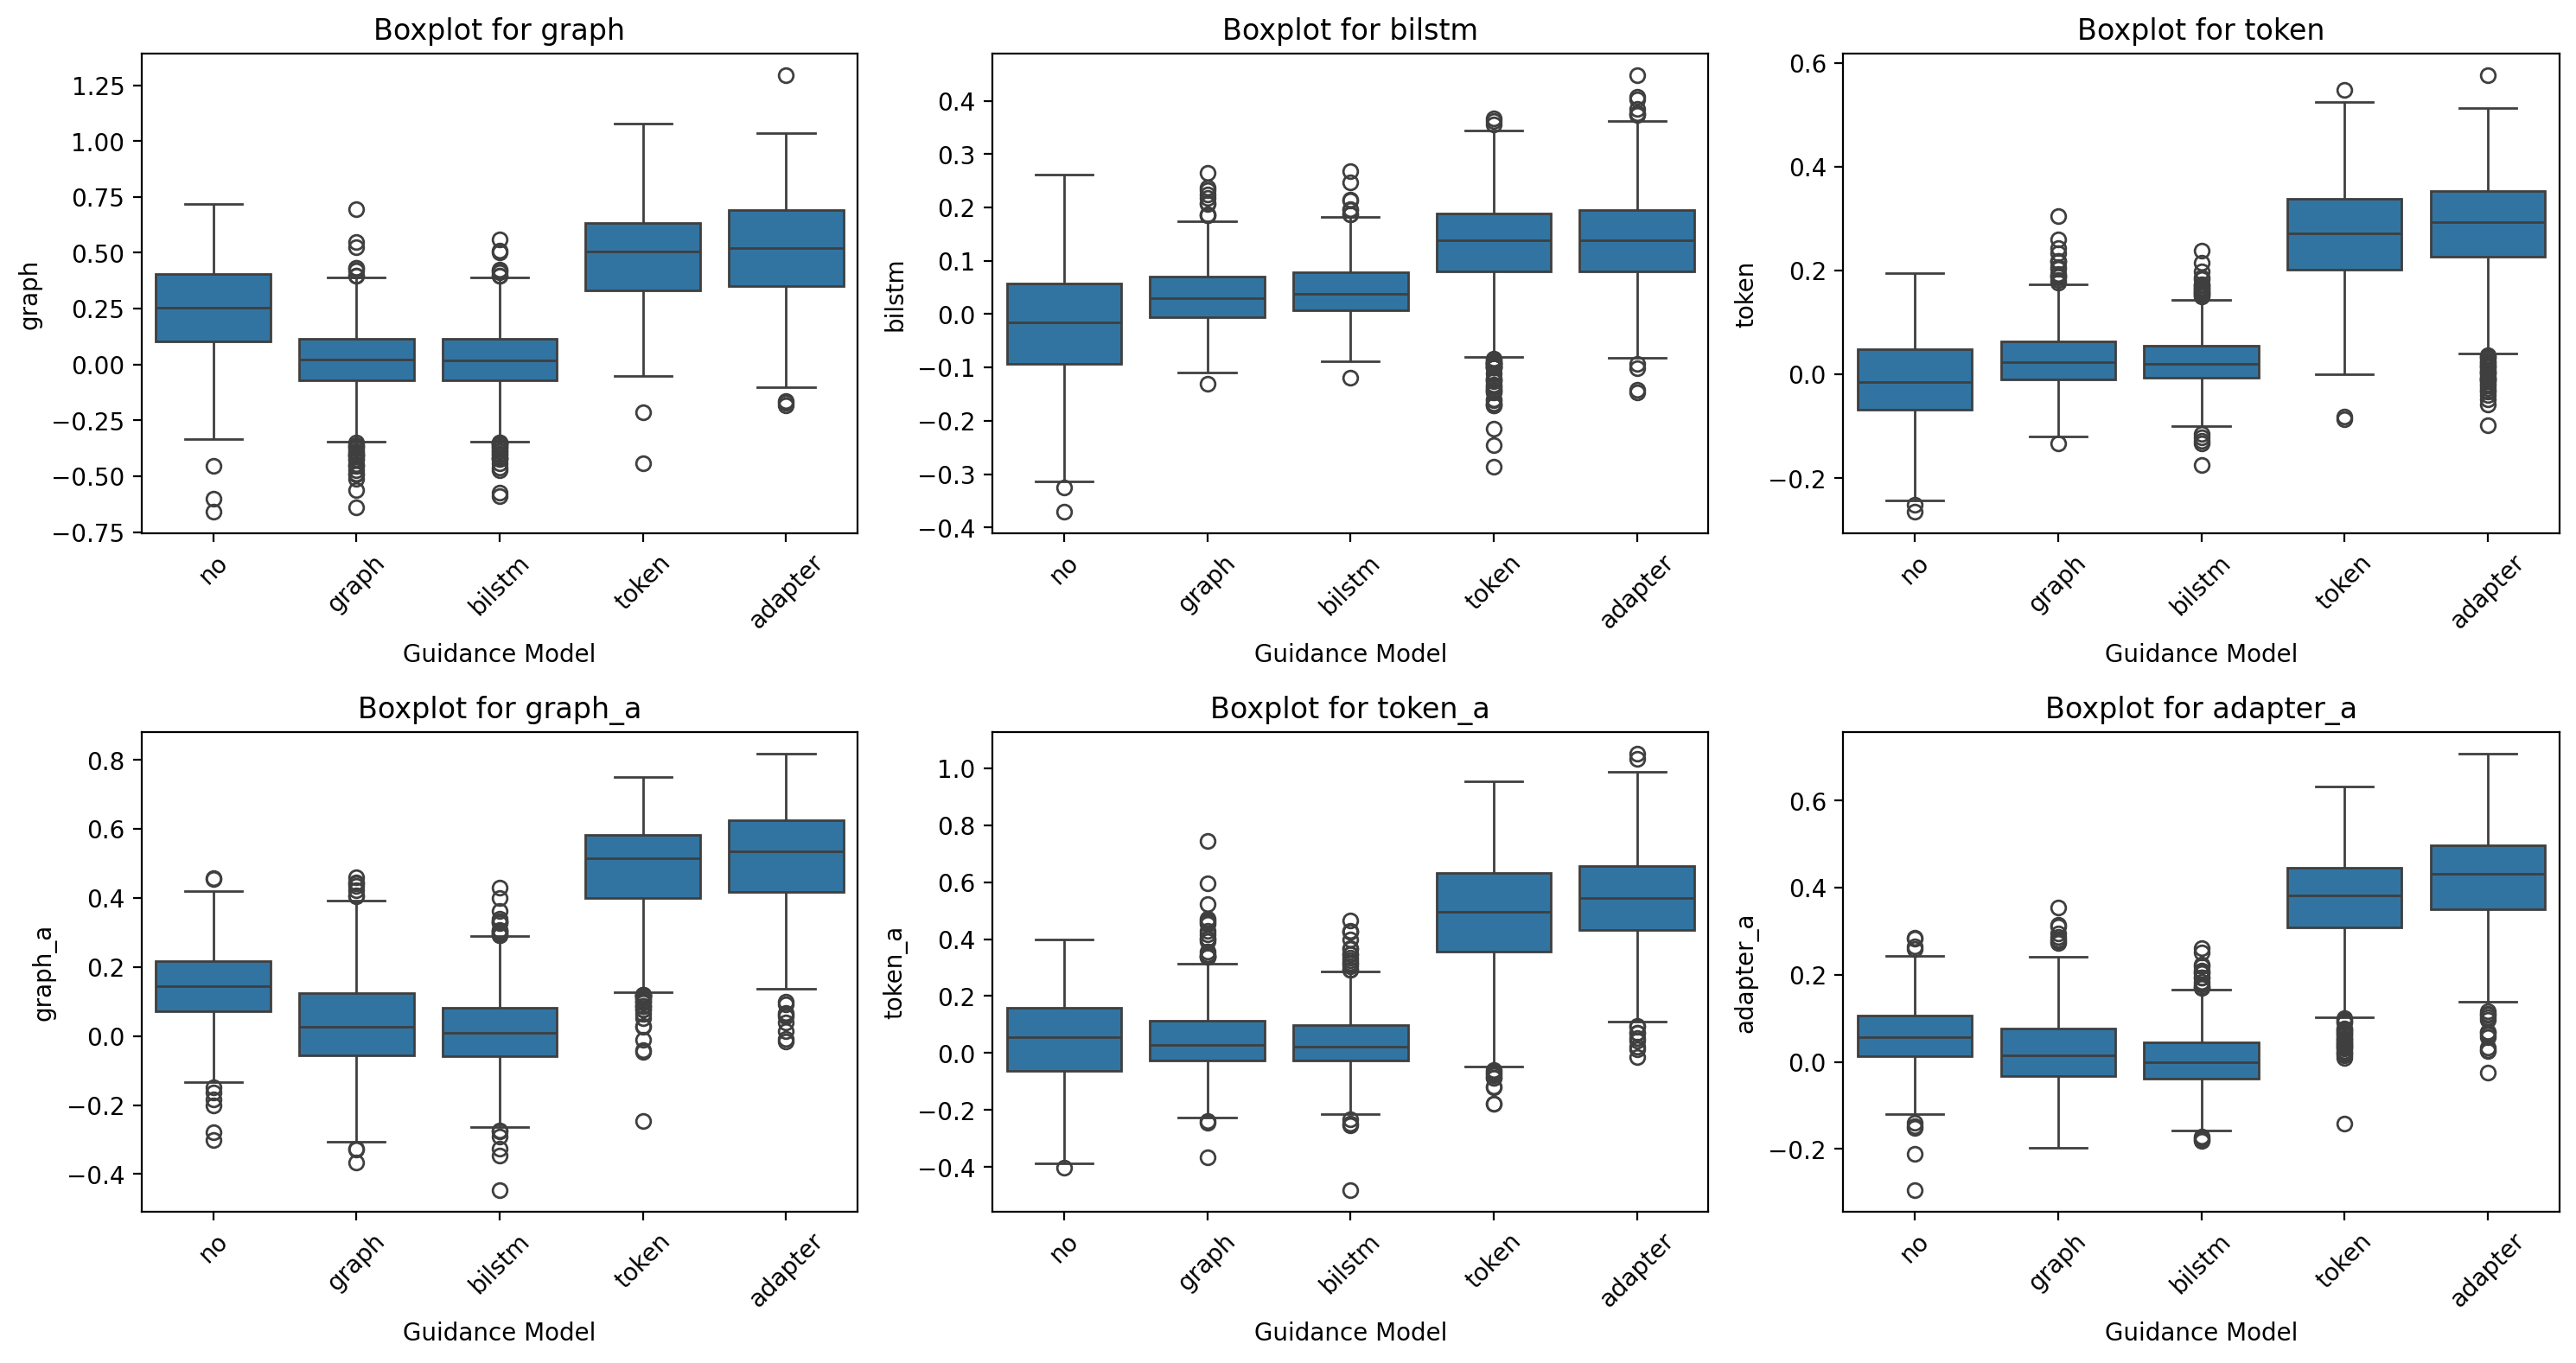

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Restrict the analysis to rows where contrastive training was enabled
# and select numeric metric columns automatically.
df_contra = df[df['contra'] == True].copy()

metrics = [
    col for col in df_contra.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_contra[col])
]

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, metric in enumerate(metrics[:len(axes)]):
    sns.boxplot(data=df_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_title(f'Boxplot for {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [23]:
from scipy import stats

# Use the same filtered subset for the statistical comparison.
df_filtered = df[df['contra'] == True].copy()
metrics = [
    col for col in df_filtered.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_filtered[col])
]
models_to_compare = ['token', 'adapter']

results = []
for metric in metrics:
    token_data = df_filtered[df_filtered['guidance_model'] == 'token'][metric]
    adapter_data = df_filtered[df_filtered['guidance_model'] == 'adapter'][metric]
    
    u_stat, p_value = stats.mannwhitneyu(token_data, adapter_data)
    results.append({
        'metric': metric,
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant': p_value < 0.05 / len(metrics)
    })

results_df = pd.DataFrame(results)
print(results_df)

      metric  u_statistic       p_value  significant
0      graph     155294.0  3.849705e-02        False
1     bilstm     160890.0  2.785759e-01        False
2      token     154937.0  3.297191e-02        False
3    graph_a     142979.0  2.241282e-05         True
4    token_a     142785.0  1.923661e-05         True
5  adapter_a     126972.0  1.667707e-12         True


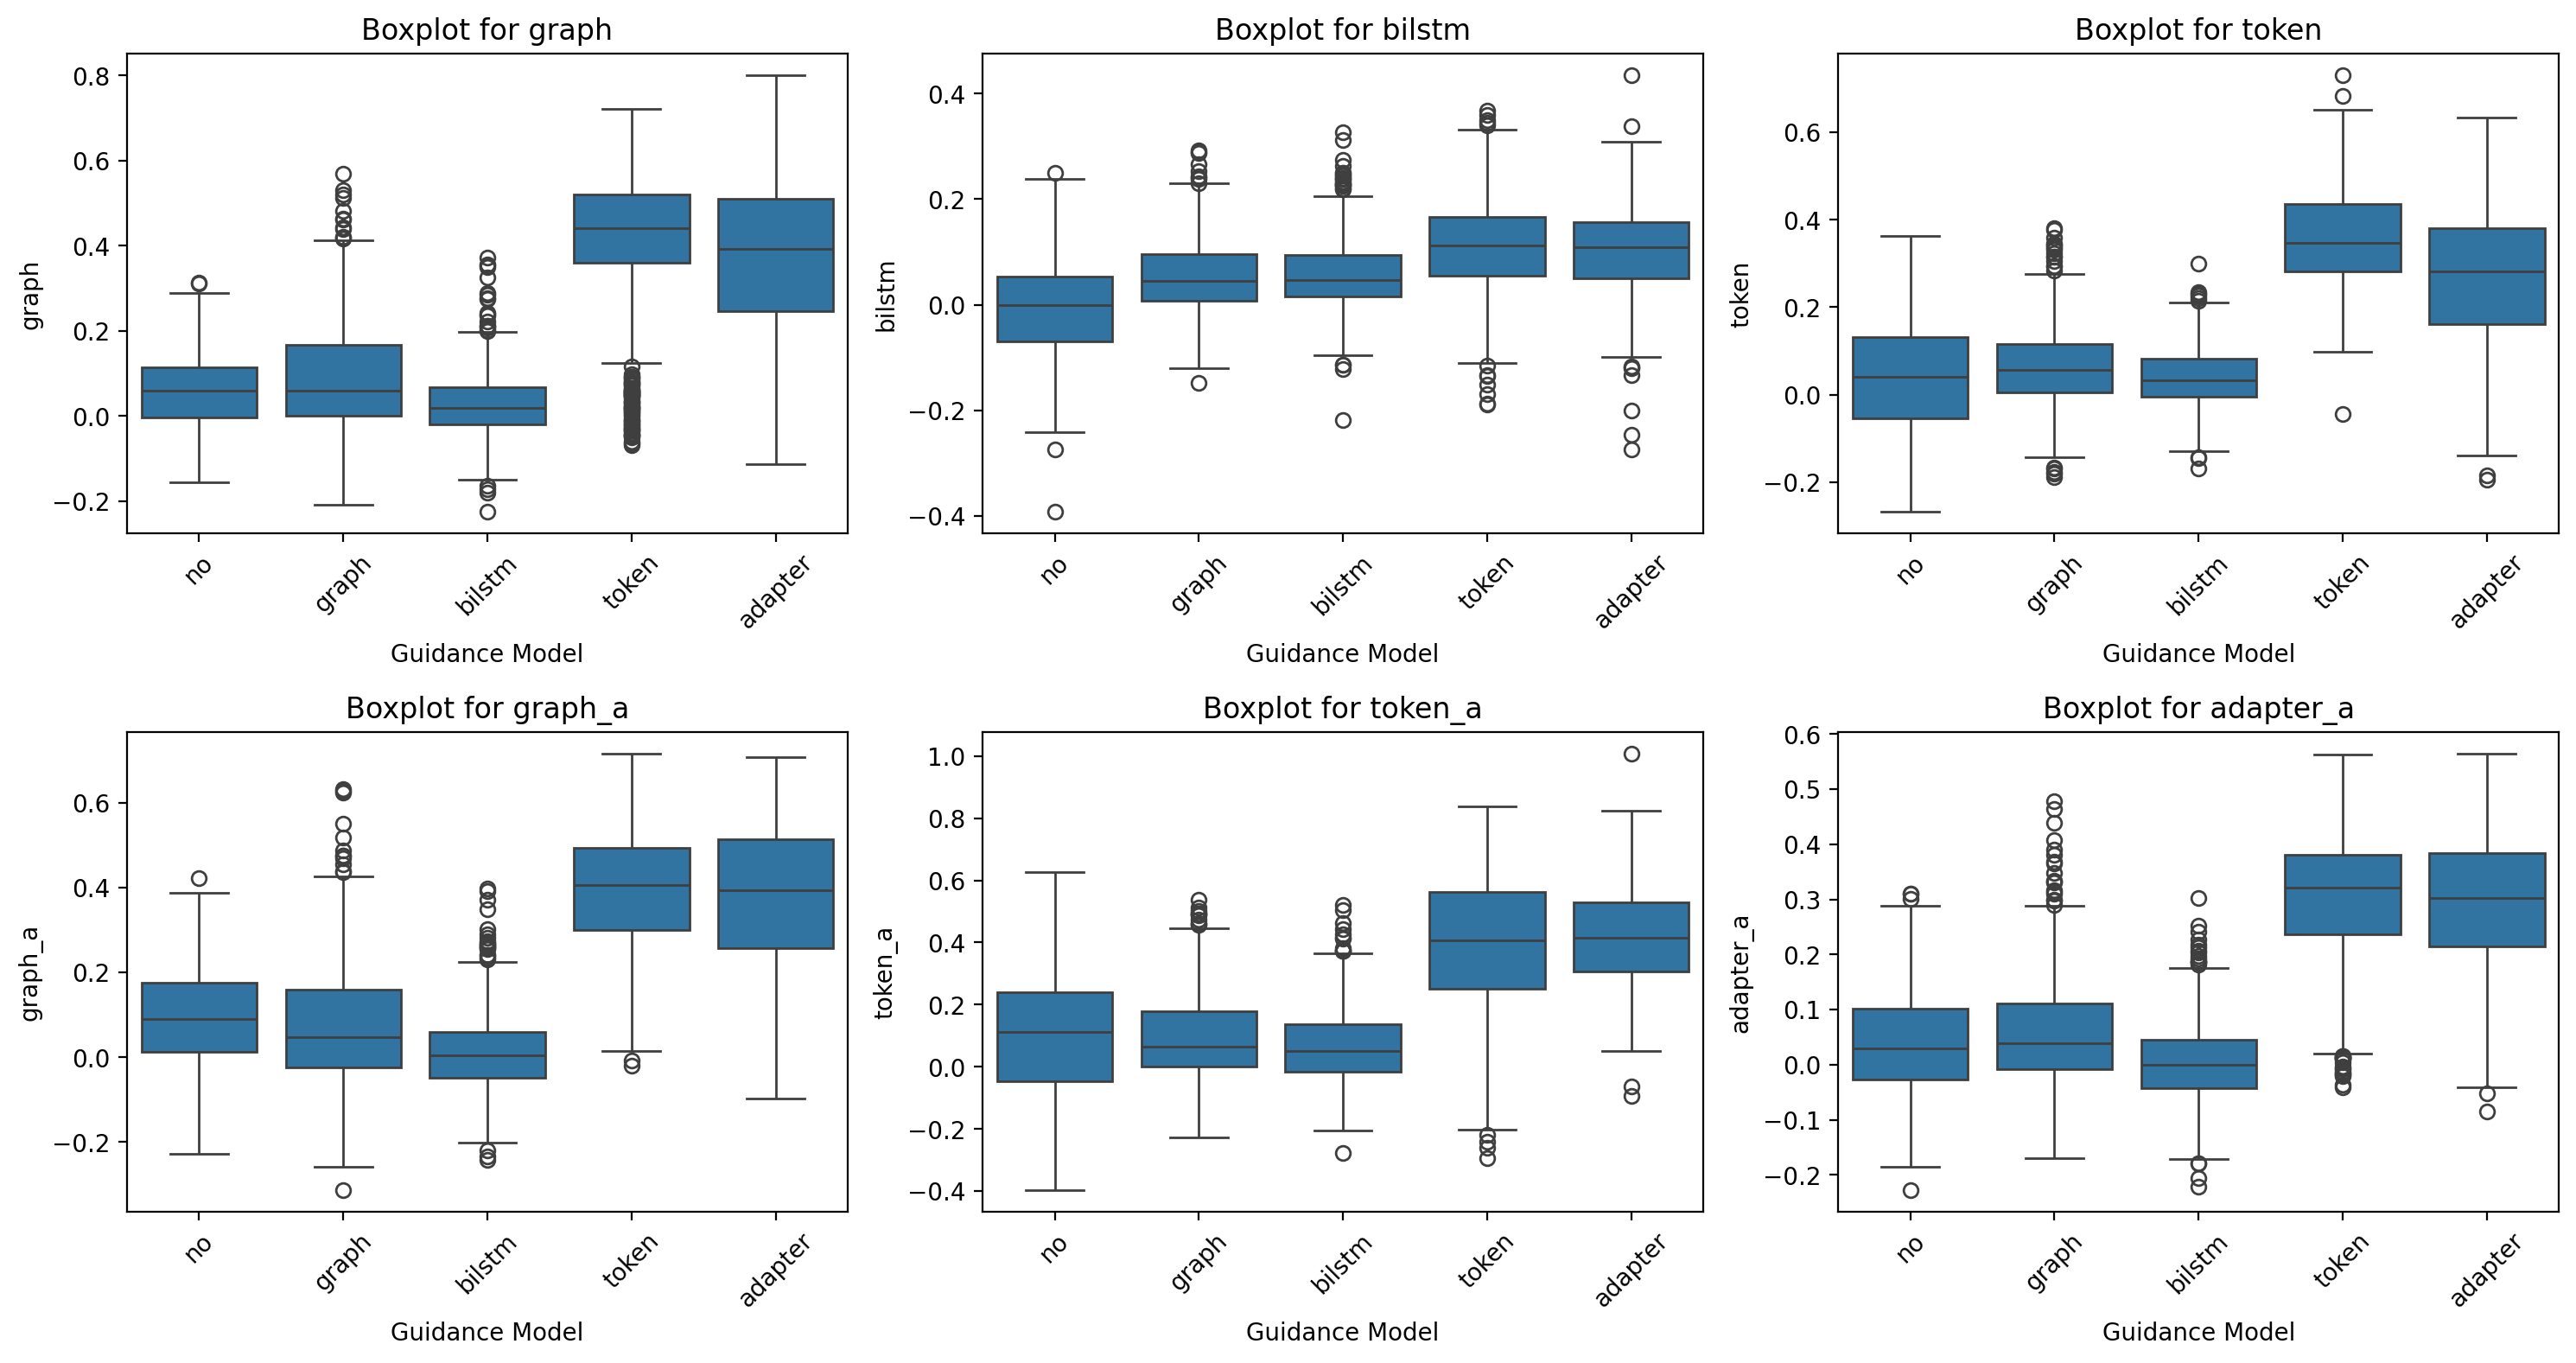

In [24]:
# Restrict the analysis to rows where contrastive training was NOT enabled
# and select numeric metric columns automatically.
df_no_contra = df[df['contra'] == False].copy()

metrics = [
    col for col in df_no_contra.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_contra[col])
]

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, metric in enumerate(metrics[:len(axes)]):
    sns.boxplot(data=df_no_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_title(f'Boxplot for {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [25]:
# Use the same filtered subset for the statistical comparison.
df_no_filtered = df[df['contra'] == False].copy()
metrics = [
    col for col in df_no_filtered.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_no_filtered[col])
]
models_to_compare = ['token', 'adapter']

results = []
for metric in metrics:
    token_data = df_no_filtered[df_no_filtered['guidance_model'] == 'token'][metric]
    adapter_data = df_no_filtered[df_no_filtered['guidance_model'] == 'adapter'][metric]
    
    u_stat, p_value = stats.mannwhitneyu(token_data, adapter_data)
    results.append({
        'metric': metric,
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant': p_value < 0.05 / len(metrics)
    })

results_df = pd.DataFrame(results)
print(results_df)

      metric  u_statistic       p_value  significant
0      graph     187544.0  1.401696e-05         True
1     bilstm     168730.0  3.310785e-01        False
2      token     216748.0  9.967687e-22         True
3    graph_a     165789.0  6.564006e-01        False
4    token_a     155827.0  1.801739e-01        False
5  adapter_a     168579.0  3.447185e-01        False


/tmp/ipykernel_2926036/3619678584.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_adapter, x='contra_label', y=metric_col, order=['non-contra', 'contra'], palette='Set2')


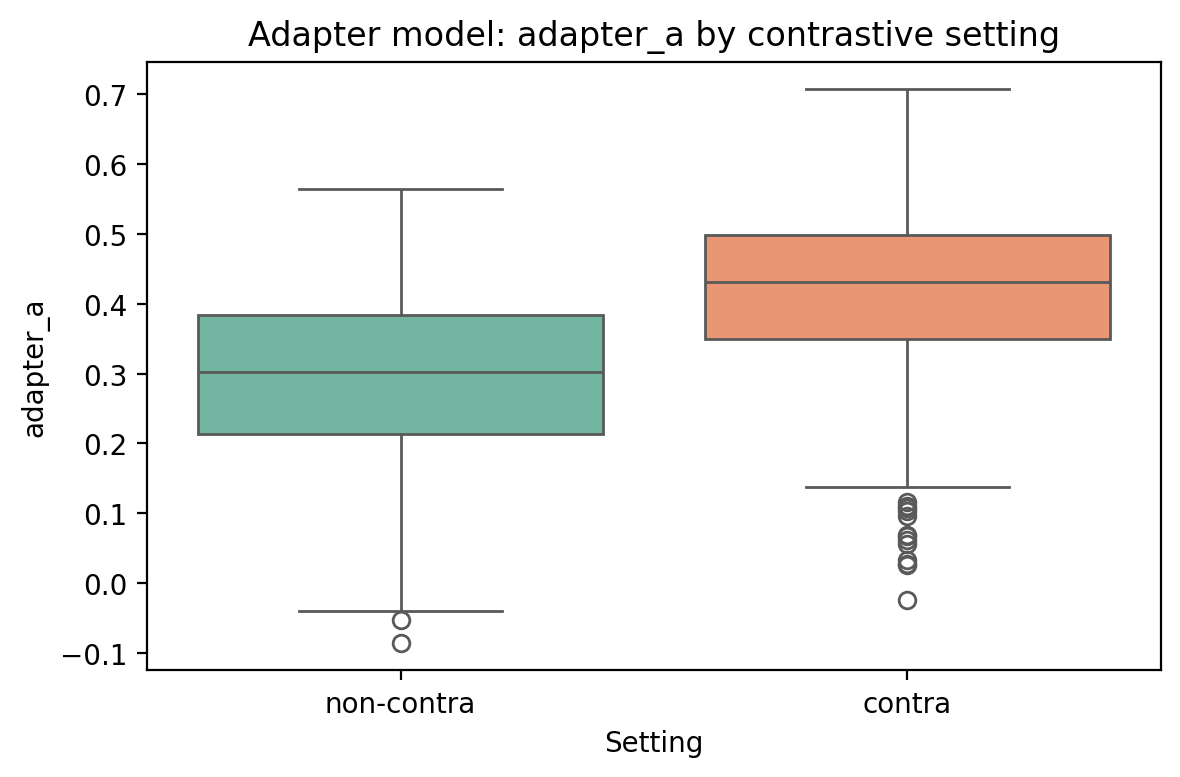

U statistic: 253816.000
p-value: 0.000000
Significant at 0.05: True


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Focus on the adapter model and pick the adapter metric column.
df_adapter = df[df['guidance_model'] == 'adapter'].copy()
metric_col = 'adapter_a' if 'adapter_a' in df_adapter.columns else next(
    (col for col in df_adapter.columns if col.startswith('adapter') and col.endswith('_a')),
    None,
)

if metric_col is None:
    raise ValueError(f"No adapter metric column found. Available columns: {df_adapter.columns.tolist()}")

# Make the contrastive labels easier to read.
df_adapter['contra_label'] = df_adapter['contra'].map({True: 'contra', False: 'non-contra'})

# Boxplot comparison.
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_adapter, x='contra_label', y=metric_col, order=['non-contra', 'contra'], palette='Set2')
plt.title(f'Adapter model: {metric_col} by contrastive setting')
plt.xlabel('Setting')
plt.ylabel(metric_col)
plt.tight_layout()
plt.show()

# Statistical significance test.
contra_true = df_adapter.loc[df_adapter['contra'] == True, metric_col].dropna()
contra_false = df_adapter.loc[df_adapter['contra'] == False, metric_col].dropna()

u_stat, p_value = stats.mannwhitneyu(contra_true, contra_false, alternative='two-sided')
print(f'U statistic: {u_stat:.3f}')
print(f'p-value: {p_value:.6f}')
print(f'Significant at 0.05: {p_value < 0.05}')

In [35]:
common = [
    'b_E:7_@2;A:9_@2',
    'b_G:7_@2;D:9_@2'
]
uncommon = [
    'b_C#:hdim7_@2;D#:min_@2',
    'b_C:dim_@2;E:maj_@2'
]
new_t_known_c = [
    'b_A:min_@2;C#:maj_@2',
    'b_G:maj_@2;A#:11_@2'
]
new_t_new_c = [
    'b_C#:maj_@2;F#:maj9_@2',
    'b_D#:minmaj7_@2;B:maj6_@2'
]

In [60]:
seq_name = common[0]

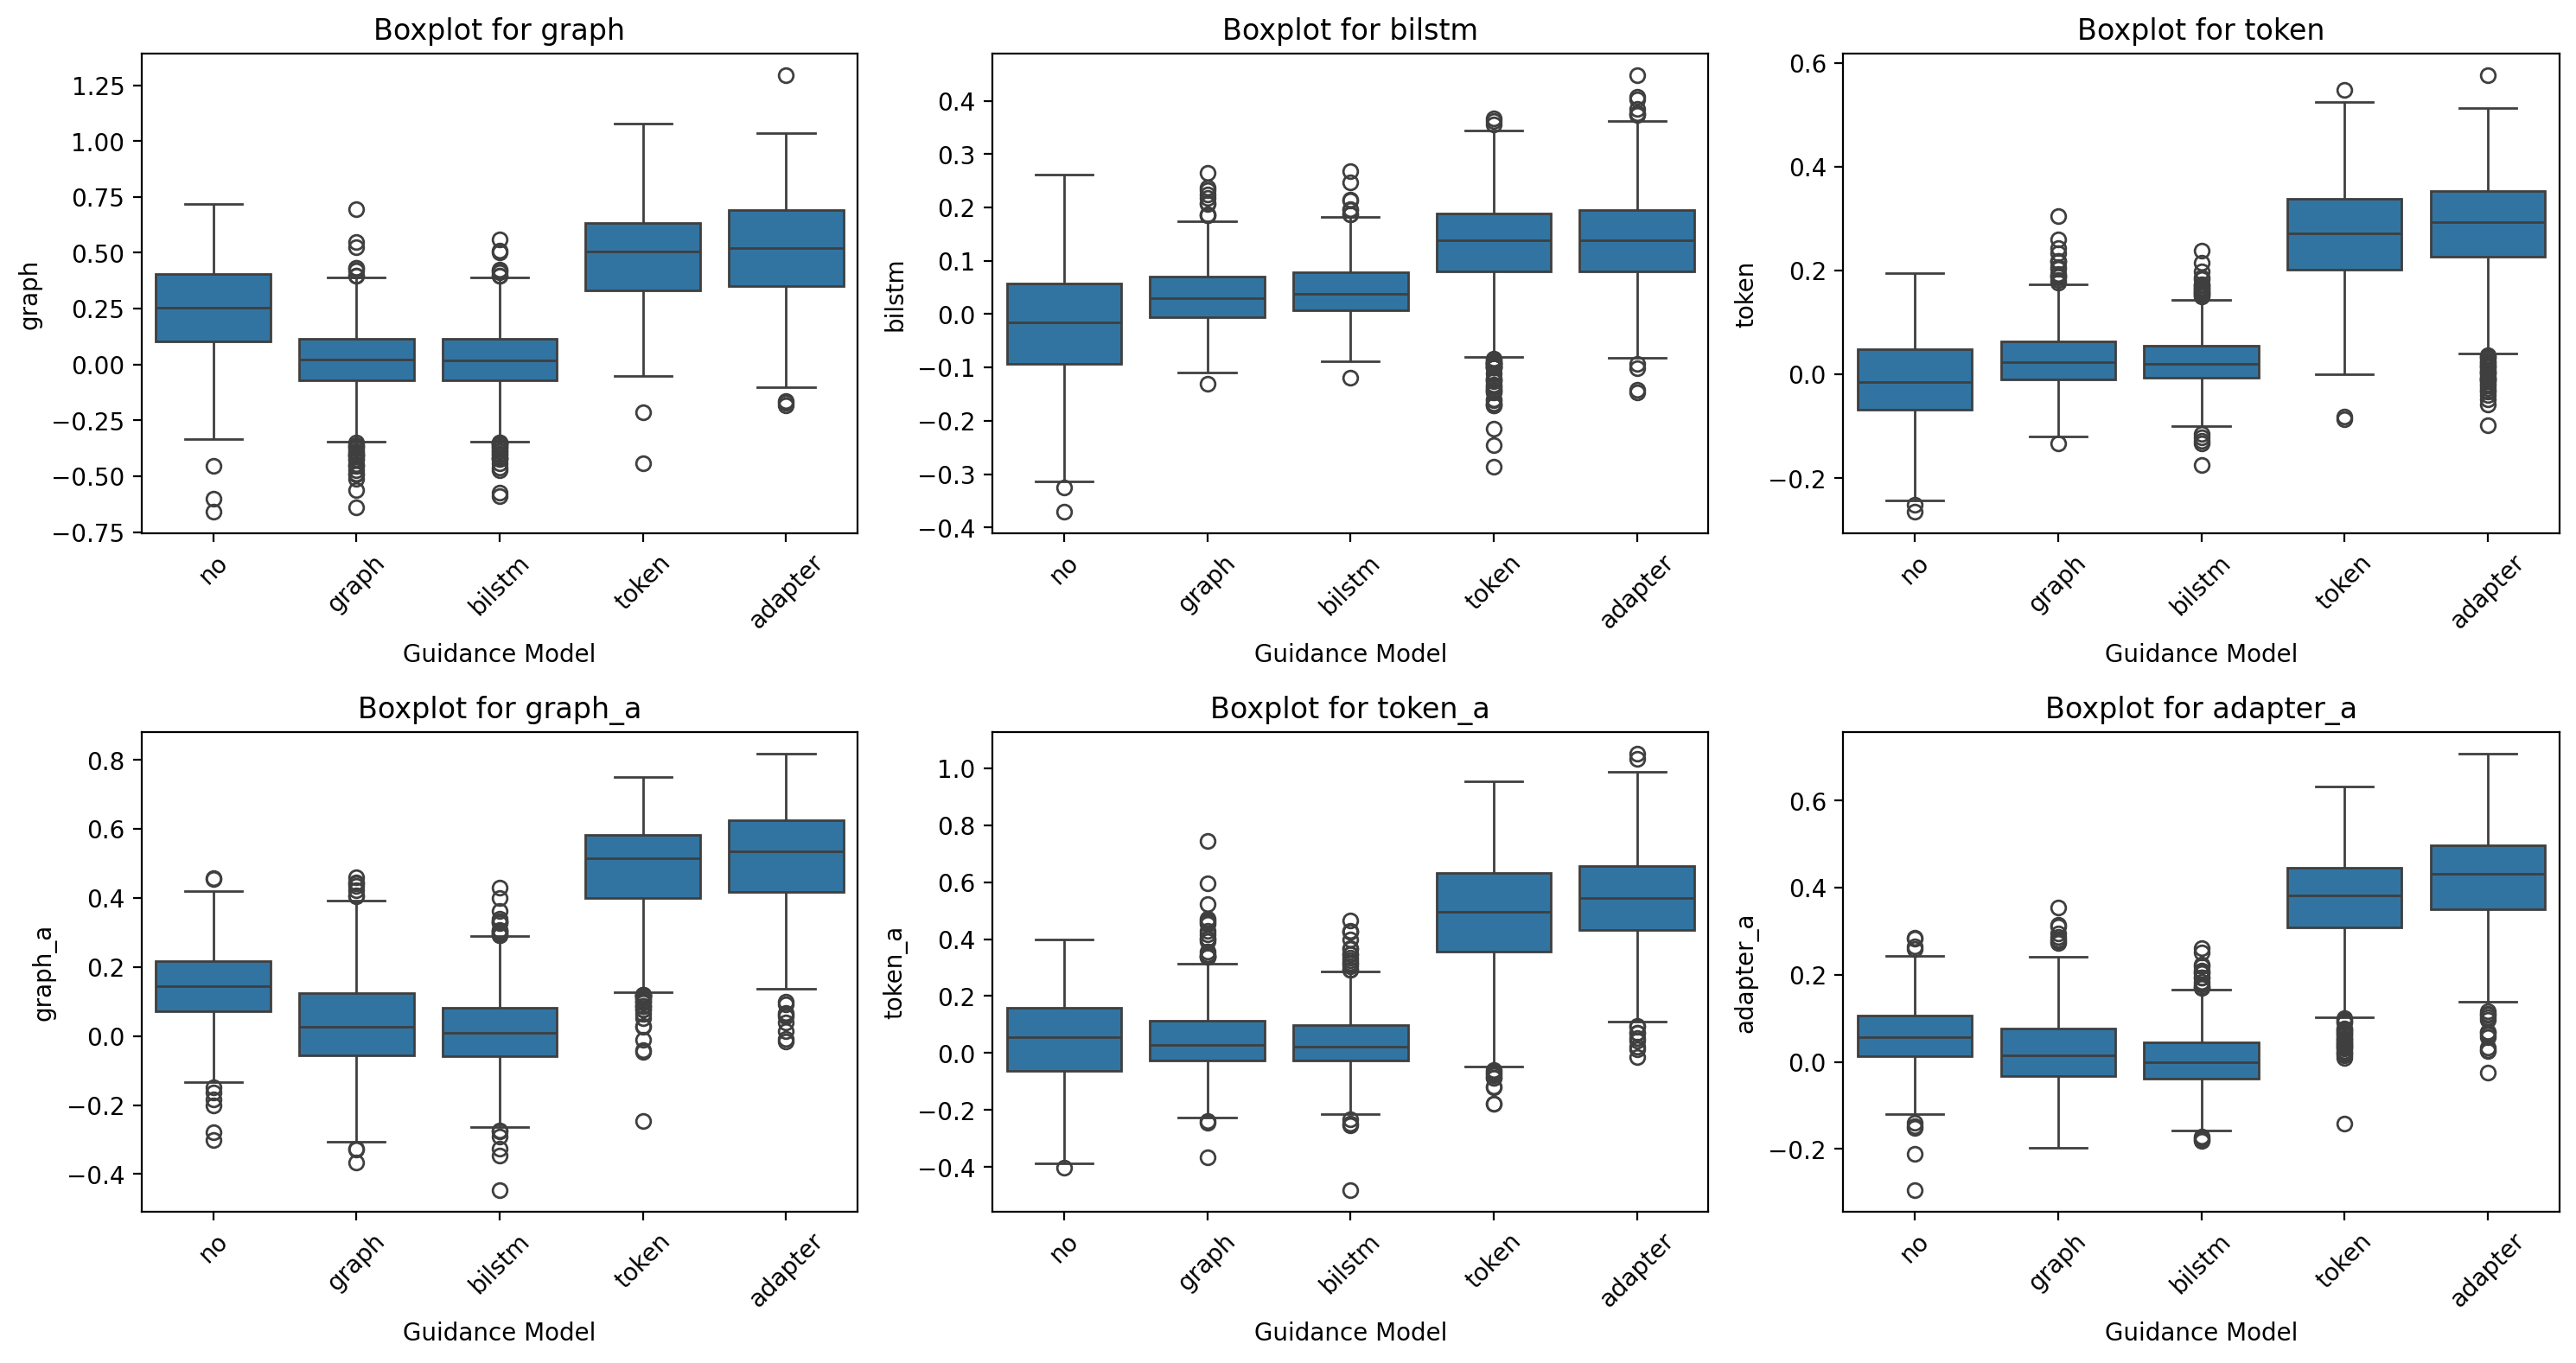

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Restrict the analysis to rows where contrastive training was enabled
# and select numeric metric columns automatically.
# df_contra = df[df['contra'] == True].copy()
df_common = df_contra[df_contra['path'].str.contains(seq_name, na=False)].copy()

metrics = [
    col for col in df_common.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_common[col])
]

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, metric in enumerate(metrics[:len(axes)]):
    sns.boxplot(data=df_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_title(f'Boxplot for {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [59]:
import numpy as np
from scipy import stats

df_common = df_contra[df_contra['path'].str.contains(seq_name, na=False)].copy()

metrics = [
    col for col in df_common.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_common[col])
]

results = []
for metric in metrics:
    token_data = df_common.loc[df_common['guidance_model'] == 'token', metric].dropna()
    adapter_data = df_common.loc[df_common['guidance_model'] == 'adapter', metric].dropna()

    if len(token_data) == 0 or len(adapter_data) == 0:
        results.append({
            'metric': metric,
            'u_statistic': np.nan,
            'p_value': np.nan,
            'significant': False,
            'note': 'missing token or adapter rows'
        })
        continue

    u_stat, p_value = stats.mannwhitneyu(token_data, adapter_data, alternative='two-sided')
    results.append({
        'metric': metric,
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant': p_value < 0.05 / len(metrics)
    })

results_df = pd.DataFrame(results)
print(results_df)

      metric  u_statistic   p_value  significant
0      graph       2714.0  0.431020        False
1     bilstm       2381.0  0.570629        False
2      token       3190.0  0.006342         True
3    graph_a       2909.0  0.113409        False
4    token_a       2892.0  0.130103        False
5  adapter_a       3191.0  0.006264         True
